# W&B Objective Group MAE Curves

Compares W&B groups that log different validation MAE variants. The W&B API key is loaded from `.slurm_tokens` without printing it.

In [1]:
from __future__ import annotations

import os
import shlex
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import wandb

plt.style.use("seaborn-v0_8-whitegrid")

## Configure

In [2]:
ENTITY = "mhenheik-eth-z-rich"
PROJECT = "cil-sentiment"

GROUP_NAMES = [
    "Soft Label",
    "Classifier MAP/Bayes",
    "Regressor",
    "Noise Weighting",
]

# Metrics produced by experiments/ordinal.py:
# - classification / ordinal_soft_ce: map_mae, bayes_mae
# - regression: rounded_mae, tuned_threshold_mae
MAE_METRICS = {
    "eval/bayes_mae": "Bayes",
    "eval/map_mae": "MAP",
    "eval/tuned_threshold_mae": "Tuned",
    "eval/rounded_mae": "Rounded",
}

METHOD_LABELS = {
    ("Classifier MAP/Bayes", "MAP"): "Classifier MAP",
    ("Classifier MAP/Bayes", "Bayes"): "Classifier Bayes",
    ("Noise Weighting", "MAP"): "Noise Weighting MAP",
    ("Noise Weighting", "Bayes"): "Noise Weighting Bayes",
    ("Regressor", "Rounded"): "Regressor Rounded",
    ("Regressor", "Tuned"): "Regressor Tuned",
    ("Soft Label", "MAP"): "Soft Labels",
}
SKIP_METHODS = {("Soft Label", "Bayes")}

X_AXIS_CANDIDATES = ["train/global_step", "global_step", "trainer/global_step"]
FALLBACK_EVAL_STEP_INTERVAL = 500
MAX_HISTORY_ROWS_PER_RUN = None

## Login

In [3]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".slurm_tokens").exists():
            return candidate
    raise FileNotFoundError("Could not find .slurm_tokens in this directory or its parents.")


def load_shell_exports(path: Path) -> dict[str, str]:
    values: dict[str, str] = {}
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("export "):
            line = line[len("export ") :]
        if "=" not in line:
            continue
        key, value = line.split("=", 1)
        values[key.strip()] = shlex.split(value)[0] if value else ""
    return values


repo_root = find_repo_root()
tokens = load_shell_exports(repo_root / ".slurm_tokens")

if "WANDB_API_KEY" not in os.environ and tokens.get("WANDB_API_KEY"):
    os.environ["WANDB_API_KEY"] = tokens["WANDB_API_KEY"]

wandb.login(key=os.environ.get("WANDB_API_KEY"), relogin=False)
api = wandb.Api()

print("Logged in to W&B. Token was loaded from .slurm_tokens and not displayed.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/micha/.netrc


wandb: Currently logged in as: mhenheik (mhenheik-eth-z-rich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged in to W&B. Token was loaded from .slurm_tokens and not displayed.


## Fetch All MAE Variants

In [4]:
def eval_step_interval(run: wandb.apis.public.Run) -> int:
    config = run.config or {}
    if isinstance(config.get("training"), dict) and config["training"].get("eval_steps"):
        return int(config["training"]["eval_steps"])
    for key in ["training.eval_steps", "eval_steps", "args/eval_steps"]:
        if config.get(key):
            return int(config[key])
    return FALLBACK_EVAL_STEP_INTERVAL


def step_from_row(row: pd.Series, fallback: int) -> int | float:
    for key in X_AXIS_CANDIDATES:
        if key in row and pd.notna(row[key]):
            return row[key]
    return fallback


def scan_run_history(run: wandb.apis.public.Run) -> pd.DataFrame:
    rows = []
    for idx, row in enumerate(run.scan_history(page_size=1000)):
        rows.append(row)
        if MAX_HISTORY_ROWS_PER_RUN is not None and idx + 1 >= MAX_HISTORY_ROWS_PER_RUN:
            break
    return pd.DataFrame(rows)


def run_mae_frames(run: wandb.apis.public.Run) -> list[pd.DataFrame]:
    history = scan_run_history(run)
    if history.empty:
        return []

    interval = eval_step_interval(run)
    frames = []
    for metric, metric_label in MAE_METRICS.items():
        if (run.group, metric_label) in SKIP_METHODS:
            continue
        if metric not in history.columns:
            continue
        metric_rows = history.loc[history[metric].notna()].copy()
        if metric_rows.empty:
            continue

        metric_rows = metric_rows.reset_index(drop=True)
        frame = pd.DataFrame(
            {
                "step": [step_from_row(row, (idx + 1) * interval) for idx, row in metric_rows.iterrows()],
                "wandb_step": metric_rows["_step"] if "_step" in metric_rows else pd.NA,
                "mae": metric_rows[metric],
            }
        ).dropna(subset=["mae"])
        frame["group"] = run.group or "<no group>"
        frame["metric"] = metric
        frame["metric_label"] = metric_label
        frame["method"] = METHOD_LABELS.get((run.group, metric_label), f"{run.group} {metric_label}")
        frame["run_name"] = run.name
        frame["run_id"] = run.id
        frames.append(frame.sort_values("step"))

    return frames


runs = list(api.runs(
    path=f"{ENTITY}/{PROJECT}",
    filters={"group": {"$in": GROUP_NAMES}},
))
print(f"Found {len(runs)} runs in groups: {GROUP_NAMES}")

frames = []
for run in runs:
    frames.extend(run_mae_frames(run))

if not frames:
    available = []
    for run in runs[:10]:
        summary_keys = sorted(key for key in run.summary.keys() if "mae" in key.lower())
        available.append({"group": run.group, "run_name": run.name, "summary_mae_keys": summary_keys})
    display(pd.DataFrame(available))
    raise RuntimeError("No MAE histories found. Check group names and MAE_METRICS.")

mae_df = pd.concat(frames, ignore_index=True)
summary = (
    mae_df.groupby(["group", "metric_label", "metric", "run_name"], as_index=False)
    .agg(points=("mae", "size"), min_mae=("mae", "min"), final_step=("step", "max"))
    .sort_values(["group", "metric_label", "min_mae"])
)
display(summary)
mae_df.head()

Found 12 runs in groups: ['Soft Label', 'Classifier MAP/Bayes', 'Regressor', 'Noise Weighting']


,group,metric_label,metric,run_name,points,min_mae,final_step
0,Classifier MAP/Bayes,Bayes,eval/bayes_mae,ordinal_ce_xlmr_seed1_lora_bert_default_classi...,22,0.382659,10632.0
1,Classifier MAP/Bayes,Bayes,eval/bayes_mae,ordinal_ce_xlmr_seed2_lora_bert_default_classi...,22,0.383056,10632.0
2,Classifier MAP/Bayes,Bayes,eval/bayes_mae,ordinal_ce_xlmr_seed3_lora_bert_default_classi...,22,0.386944,10632.0
3,Classifier MAP/Bayes,MAP,eval/map_mae,ordinal_ce_xlmr_seed1_lora_bert_default_classi...,22,0.384365,10632.0
4,Classifier MAP/Bayes,MAP,eval/map_mae,ordinal_ce_xlmr_seed2_lora_bert_default_classi...,22,0.388770,10632.0
5,Classifier MAP/Bayes,MAP,eval/map_mae,ordinal_ce_xlmr_seed3_lora_bert_default_classi...,22,0.389722,10632.0
6,Noise Weighting,Bayes,eval/bayes_mae,noise_weight_q5_xlmr_seed1_lora_bert_default_c...,22,0.381310,10632.0
7,Noise Weighting,Bayes,eval/bayes_mae,noise_weight_q5_xlmr_seed2_lora_bert_default_c...,22,0.381944,10632.0
8,Noise Weighting,Bayes,eval/bayes_mae,noise_weight_q5_xlmr_seed3_lora_bert_default_c...,22,0.385595,10632.0
9,Noise Weighting,MAP,eval/map_mae,noise_weight_q5_xlmr_seed1_lora_bert_default_c...,22,0.382500,10632.0


,step,wandb_step,mae,group,metric,metric_label,method,run_name,run_id
0,500.0,1,0.454563,Classifier MAP/Bayes,eval/bayes_mae,Bayes,Classifier Bayes,ordinal_ce_xlmr_seed1_lora_bert_default_classi...,e5n9xypo
1,1000.0,3,0.422063,Classifier MAP/Bayes,eval/bayes_mae,Bayes,Classifier Bayes,ordinal_ce_xlmr_seed1_lora_bert_default_classi...,e5n9xypo
2,1500.0,5,0.411746,Classifier MAP/Bayes,eval/bayes_mae,Bayes,Classifier Bayes,ordinal_ce_xlmr_seed1_lora_bert_default_classi...,e5n9xypo
3,2000.0,7,0.407500,Classifier MAP/Bayes,eval/bayes_mae,Bayes,Classifier Bayes,ordinal_ce_xlmr_seed1_lora_bert_default_classi...,e5n9xypo
4,2500.0,9,0.405357,Classifier MAP/Bayes,eval/bayes_mae,Bayes,Classifier Bayes,ordinal_ce_xlmr_seed1_lora_bert_default_classi...,e5n9xypo


## Plot

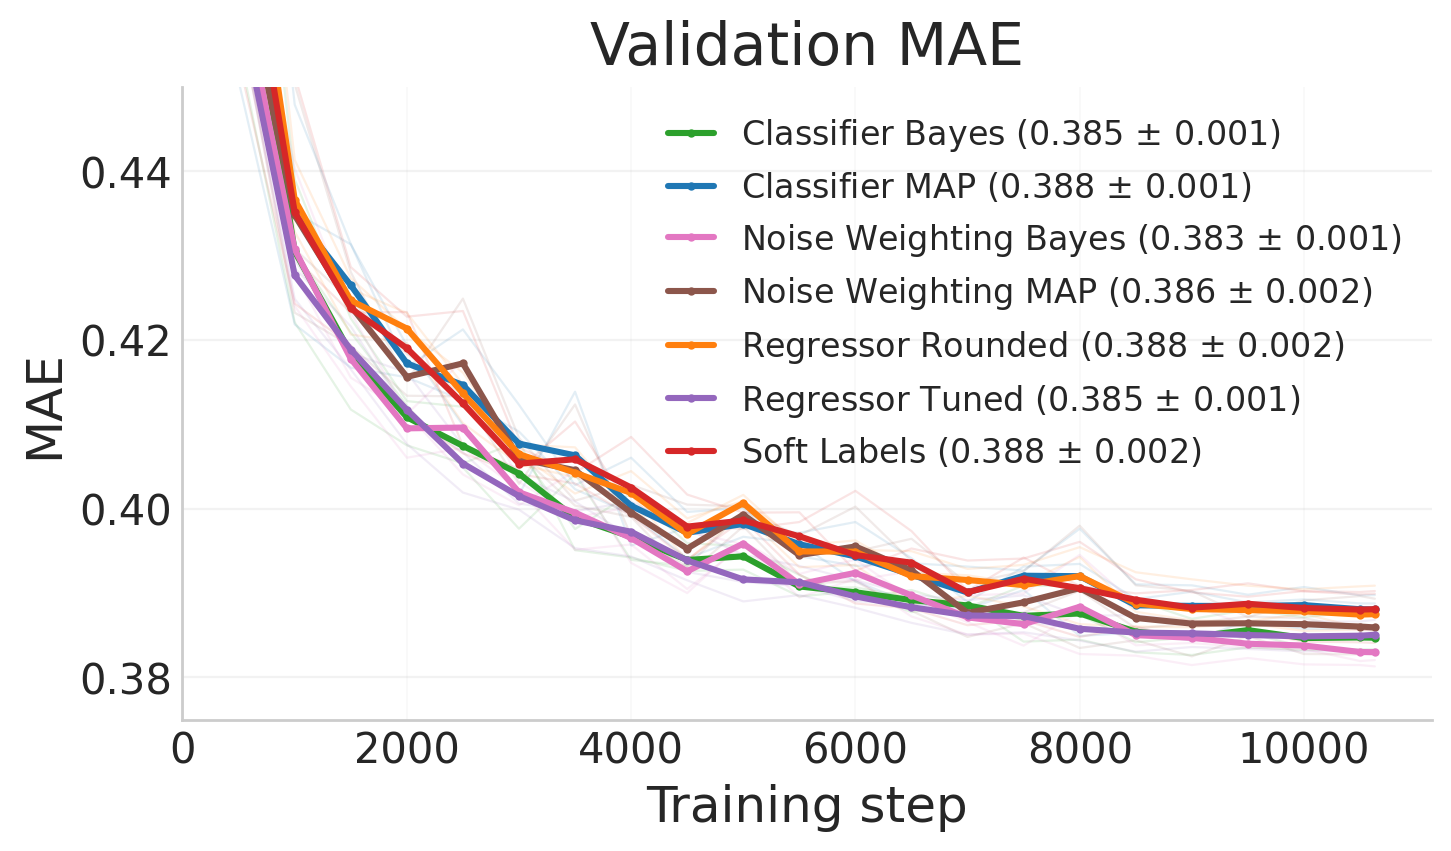

In [7]:
with plt.rc_context({
    "font.size": 17,
    "axes.titlesize": 21,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12,
    "lines.linewidth": 1.8,
}):
    fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=200)
    palette = list(plt.get_cmap("tab10").colors)
    shuffled_palette = [palette[i] for i in [2, 0, 4, 1, 3, 6, 5, 8, 7, 9]]
    method_colors = {
        method: shuffled_palette[idx % len(shuffled_palette)]
        for idx, method in enumerate(mae_df["method"].drop_duplicates())
    }

    for (method, run_name), run_df in mae_df.groupby(["method", "run_name"], sort=False):
        ax.plot(
            run_df["step"],
            run_df["mae"],
            color=method_colors[method],
            linewidth=0.8,
            alpha=0.12,
            label=None,
        )

    mean_df = (
        mae_df.groupby(["method", "step"], as_index=False)["mae"]
        .mean()
        .sort_values(["method", "step"])
    )
    final_stats = (
        mae_df.sort_values("step")
        .groupby(["method", "run_name"], as_index=False)
        .tail(1)
        .groupby("method")["mae"]
        .agg(final_mean="mean", final_std="std", runs="count")
    )
    final_stats["final_se"] = final_stats["final_std"].fillna(0) / (final_stats["runs"] ** 0.5)

    for method, method_df in mean_df.groupby("method", sort=False):
        final_mae = final_stats.loc[method, "final_mean"]
        final_se = final_stats.loc[method, "final_se"]
        ax.plot(
            method_df["step"],
            method_df["mae"],
            color=method_colors[method],
            linewidth=2.2,
            marker="o",
            markersize=3.0,
            markeredgewidth=0,
            label=f"{method} ({final_mae:.3f} $\\pm$ {final_se:.3f})",
        )

    ax.set_title("Validation MAE", pad=8)
    ax.set_xlabel("Training step")
    ax.set_ylabel("MAE")
    ax.set_ylim(top=0.45)
    ax.legend(frameon=False, loc="upper right", handlelength=1.4)
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
    ax.grid(True, axis="x", alpha=0.12, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout(pad=0.3)
    plt.show()

## Final Values

In [6]:
final_values = (
    mae_df.sort_values("step")
    .groupby(["method", "run_name"], as_index=False)
    .tail(1)
    .groupby("method", as_index=False)
    .agg(final_mae_mean=("mae", "mean"), final_mae_std=("mae", "std"), runs=("run_id", "nunique"))
    .sort_values("final_mae_mean")
)
display(final_values)

,method,final_mae_mean,final_mae_std,runs
2,Noise Weighting Bayes,0.382989,0.002288,3
0,Classifier Bayes,0.384709,0.002592,3
5,Regressor Tuned,0.385053,0.001786,3
3,Noise Weighting MAP,0.385926,0.003230,3
4,Regressor Rounded,0.387500,0.002929,3
1,Classifier MAP,0.388056,0.002154,3
6,Soft Labels,0.388082,0.003463,3
